<a href="https://colab.research.google.com/github/DastanJin/ZSU/blob/main/Project1_SUS0112.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Analýza cen počítačů pomocí shlukování
(clustering)

Úvod a cíle analýzy

V této analýze zkoumáme, zda lze pomocí metod shlukové analýzy (clusteringu) identifikovat předražené či podhodnocené počítače v datech e-shopu. Cílem je rozdělit počítače do skupin podle výkonových parametrů a následně odhalit modely, jejichž cena se významně odchyluje od typické ceny své skupiny. Takové odchylky mohou indikovat předražené produkty (cena neúměrně vysoká vzhledem k výkonu) nebo naopak výhodné nabídky (podhodnocené, nabízející vysoký výkon za nečekaně nízkou cenu). Tato metodika může sloužit k automatizované kontrole cen v e-shopu, doporučování nejvýhodnějších produktů či obecně k detekci anomálií v produktových datech.

Pro analýzu máme k dispozici datový soubor obsahující informace o stolních počítačích a noteboocích (laptop/desktop), jejich hardwarových specifikacích a prodejní ceně. Budeme využívat strojové učení bez učitele: zejména algoritmy K-Means a Gaussian Mixture Model (GMM) pro shlukování, metody pro hodnocení kvality shluků (silhouette score, elbow metoda) a také Principal Component Analysis (PCA) pro snížení dimenze a vizualizaci. Před aplikací těchto metod provedeme důkladné předzpracování dat, včetně škálování číselných znaků pomocí standardizace.


In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

plt.style.use("ggplot")
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_context("talk")

Prvotni kontrola dat

In [5]:
df = pd.read_csv("computer_prices_all.csv")
import pandas as pd


print(df.head())
print(df.info())


  device_type     brand              model  release_year       os form_factor  \
0     Desktop   Samsung  Samsung Forge XDI          2022  Windows         ATX   
1      Laptop   Samsung    Samsung Pro KM8          2022  Windows  Mainstream   
2     Desktop    Lenovo   Lenovo Strix BIE          2024    macOS         SFF   
3     Desktop      Dell      Dell Cube AXR          2024  Windows         ATX   
4      Laptop  Gigabyte   Gigabyte Pro IX1          2024    Linux      Gaming   

  cpu_brand         cpu_model  cpu_tier  cpu_cores  ...  resolution  \
0     Intel    Intel i5-11129         3         12  ...   2560x1440   
1     Intel    Intel i7-11114         4         12  ...   1920x1080   
2       AMD  AMD Ryzen 5 5168         2          8  ...   3440x1440   
3       AMD  AMD Ryzen 5 7550         2          6  ...   3440x1440   
4       AMD  AMD Ryzen 7 6230         5         16  ...   2560x1600   

   refresh_hz  battery_wh charger_watts psu_watts     wifi  bluetooth  \
0          90

Popis dat a předzpracování

**Sloupce a jejich význam (stručně):**
- `device_type` – typ zařízení (např. laptop, desktop).
- `brand` – výrobce / značka počítače.
- `model` – konkrétní model.
- `release_year` – rok uvedení na trh.
- `os` – operační systém.
- `form_factor` – fyzická forma (např. tower, mini, ultrabook).
- `cpu_brand` – výrobce CPU (Intel/AMD/…).
- `cpu_model` – konkrétní model CPU.
- `cpu_tier` – výkonnostní “tier” CPU (číslo – vyšší = výkonnější).
- `cpu_cores` – počet jader CPU.
- `cpu_threads` – počet vláken CPU.
- `cpu_base_ghz` – základní frekvence CPU.
- `cpu_boost_ghz` – boost frekvence CPU.
- `gpu_brand` – výrobce GPU.
- `gpu_model` – konkrétní model GPU.
- `gpu_tier` – výkonnostní “tier” GPU (číslo – vyšší = výkonnější).
- `vram_gb` – velikost VRAM grafiky v GB.
- `ram_gb` – velikost RAM v GB.
- `storage_type` – typ úložiště (SSD/HDD/NVMe…).
- `storage_gb` – kapacita úložiště v GB.
- `storage_drive_count` – počet disků.
- `display_type` – typ displeje (IPS/TN/OLED…).
- `display_size_in` – úhlopříčka displeje v palcích.
- `resolution` – rozlišení displeje.
- `refresh_hz` – obnovovací frekvence displeje.
- `battery_wh` – kapacita baterie v Wh.
- `charger_watts` – výkon nabíječky ve wattech.
- `psu_watts` – výkon zdroje (u desktopů) ve wattech.
- `wifi` – typ / verze Wi-Fi modulu.
- `bluetooth` – verze Bluetooth (často číselná).
- `weight_kg` – hmotnost zařízení v kg.
- `warranty_months` – délka záruky v měsících.
- `price` – cílová cena zařízení (kontinuální proměnná, důležitá pro interpretaci clusterů).

In [6]:
pd.set_option("display.max_columns", None)
df.head()


,device_type,brand,model,release_year,os,form_factor,cpu_brand,cpu_model,cpu_tier,cpu_cores,cpu_threads,cpu_base_ghz,cpu_boost_ghz,gpu_brand,gpu_model,gpu_tier,vram_gb,ram_gb,storage_type,storage_gb,storage_drive_count,display_type,display_size_in,resolution,refresh_hz,battery_wh,charger_watts,psu_watts,wifi,bluetooth,weight_kg,warranty_months,price
0,Desktop,Samsung,Samsung Forge XDI,2022,Windows,ATX,Intel,Intel i5-11129,3,12,24,2.8,3.8,NVIDIA,RTX 40 60,2,6,16,NVMe,1024,1,LED,27.0,2560x1440,90,0,0,750,Wi-Fi 6,5.1,11.00,36,1383.99
1,Laptop,Samsung,Samsung Pro KM8,2022,Windows,Mainstream,Intel,Intel i7-11114,4,12,24,2.6,3.6,NVIDIA,RTX 40 80,4,10,64,NVMe,512,1,OLED,16.0,1920x1080,90,56,120,0,Wi-Fi 6,5.3,2.03,12,2274.99
2,Desktop,Lenovo,Lenovo Strix BIE,2024,macOS,SFF,AMD,AMD Ryzen 5 5168,2,8,16,2.6,3.6,NVIDIA,RTX 40 50,1,4,8,NVMe,512,2,LED,32.0,3440x1440,120,0,0,850,Wi-Fi 6,5.0,7.00,24,1879.99
3,Desktop,Dell,Dell Cube AXR,2024,Windows,ATX,AMD,AMD Ryzen 5 7550,2,6,12,2.6,3.6,AMD,RX 7000 60,2,6,16,HDD,512,2,IPS,27.0,3440x1440,120,0,0,650,Wi-Fi 6,5.2,6.00,36,1331.99
4,Laptop,Gigabyte,Gigabyte Pro IX1,2024,Linux,Gaming,AMD,AMD Ryzen 7 6230,5,16,32,2.8,3.9,NVIDIA,RTX 30 80 Ti,5,12,96,NVMe,256,1,Mini-LED,15.6,2560x1600,90,80,90,0,Wi-Fi 6,5.2,1.50,12,2681.99


Zjistím, v kolika řádcích má každý sloupec NaN

In [7]:
null_counts = df.isna().sum().sort_values(ascending=False)
print(null_counts)

device_type            0
brand                  0
model                  0
release_year           0
os                     0
form_factor            0
cpu_brand              0
cpu_model              0
cpu_tier               0
cpu_cores              0
cpu_threads            0
cpu_base_ghz           0
cpu_boost_ghz          0
gpu_brand              0
gpu_model              0
gpu_tier               0
vram_gb                0
ram_gb                 0
storage_type           0
storage_gb             0
storage_drive_count    0
display_type           0
display_size_in        0
resolution             0
refresh_hz             0
battery_wh             0
charger_watts          0
psu_watts              0
wifi                   0
bluetooth              0
weight_kg              0
warranty_months        0
price                  0
dtype: int64


In [8]:
import plotly.express as px

categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

for col in categorical_cols:
    unique_count = df[col].nunique()

    # interaktivní grafy jen pro sloupce s ≤ 30 unikáty
    if unique_count <= 30:
        vc = df[col].value_counts().reset_index()
        vc.columns = [col, "count"]

        fig = px.bar(vc, x=col, y="count", title=f"{col} – count (unique={unique_count})",
                     text="count")
        fig.update_traces(textposition='outside')
        fig.show()
    else:
        print(f"Přeskakuji {col} (má {unique_count} unikátů — příliš mnoho pro barplot).")


Přeskakuji model (má 99036 unikátů — příliš mnoho pro barplot).


Přeskakuji cpu_model (má 26971 unikátů — příliš mnoho pro barplot).


Přeskakuji gpu_model (má 49 unikátů — příliš mnoho pro barplot).


### Výběr vhodných features pro clustering

**Myšlenka:** Pro clustering chci hlavně technické parametry, které popisují výkon a výbavu, ne marketingové názvy.

**Kategorické featury – ponechám (one-hot):**
- `device_type` – rozlišuje notebook/desktop, zásadní rozdíl konstrukce a ceny.
- `os` – typ OS ovlivňuje cílový segment a cenu.
- `cpu_brand` – Intel vs AMD může ovlivňovat výkon/cenu.
- `gpu_brand` – NVIDIA vs AMD / integrované → jiný výkon a cenová hladina.

**Kategorické featury – vyřadím:**
- `brand` – výrobce (Samsung, Dell, Lenovo…) → spíš marketing, cenu často zkresluje a nechci, aby cluster byl “jen podle značky”.
- `form_factor` – detail konstrukce (ATX, SFF…), pro základní clustering nepotřebný.
- `storage_type` – SSD/HDD/NVMe, už je částečně zachycen výkonem/cenou, můžeme ignorovat.
- `display_type` – IPS/OLED/LED, jemný rozdíl, na první verzi clusteringu ho vynechám.
- `resolution` – textový sloupec, kombinace čísel, nechci ho teď parsovat.
- `wifi` – typ Wi-Fi není pro clustering zásadní.
- `model`, `cpu_model`, `gpu_model` – konkrétní názvy modelů, obrovská kardinalita, nedává smysl je one-hotovat (dělaly by šum).

**Numerické featury – zachovám:**
- `release_year` – novější zařízení mají jiné parametry i cenu.
- `cpu_tier`, `cpu_cores`, `cpu_threads`, `cpu_base_ghz`, `cpu_boost_ghz` – popisují výkonnost CPU.
- `gpu_tier`, `vram_gb` – popisují výkonnost GPU.
- `ram_gb` – zásadní pro výkon/cenu.
- `storage_gb`, `storage_drive_count` – kapacita a počet disků, vliv na cenu.
- `display_size_in`, `refresh_hz` – kvalita/velikost displeje, relevantní.
- `battery_wh`, `charger_watts`, `psu_watts` – napájení a výdrž, jiné segmenty trhu.
- `bluetooth` – verze BT jako číslo, drobný ale použitelný parametr.
- `weight_kg` – přenositelnost vs desktop, dopad na typ produktu.
- `warranty_months` – delší záruka může korelovat s cenou/kvalitou.

**Numerické featury – speciální zacházení:**
- `price` – nechám **mimo vstup pro clustering**, aby clustery nevznikaly primárně podle ceny; `price` si nechám v původním `df` pro pozdější analýzu rozdílů cen mezi clustery.

Výsledek:
- Vytvořím nový DataFrame pouze z vybraných features.
- Kategorické zakóduju pomocí one-hot encodingu.
- Numerické sloupce znormalizuji pomocí `StandardScaler` → vznikne `df_scaled`, připravený pro KMeans.


In [9]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

cat_keep = ["device_type", "os", "cpu_brand", "gpu_brand"]

cat_drop = [
    "brand",
    "form_factor",
    "storage_type",
    "display_type",
    "resolution",
    "wifi",
    "model",
    "cpu_model",
    "gpu_model",
]

num_keep = [
    "release_year",
    "cpu_tier",
    "cpu_cores",
    "cpu_threads",
    "cpu_base_ghz",
    "cpu_boost_ghz",
    "gpu_tier",
    "vram_gb",
    "ram_gb",
    "storage_gb",
    "storage_drive_count",
    "display_size_in",
    "refresh_hz",
    "battery_wh",
    "charger_watts",
    "psu_watts",
    "bluetooth",
    "weight_kg",
    "warranty_months",
]

target_like = ["price"]

df_features = df[cat_keep + num_keep].copy()

df_encoded = pd.get_dummies(df_features, columns=cat_keep, drop_first=True)

scaler = StandardScaler()
df_encoded[num_keep] = scaler.fit_transform(df_encoded[num_keep])

df_scaled = df_encoded

print("Shape df_scaled:", df_scaled.shape)
df_scaled.head()


Shape df_scaled: (100000, 28)


,release_year,cpu_tier,cpu_cores,cpu_threads,cpu_base_ghz,cpu_boost_ghz,gpu_tier,vram_gb,ram_gb,storage_gb,storage_drive_count,display_size_in,refresh_hz,battery_wh,charger_watts,psu_watts,bluetooth,weight_kg,warranty_months,device_type_Laptop,os_Linux,os_Windows,os_macOS,cpu_brand_Apple,cpu_brand_Intel,gpu_brand_Apple,gpu_brand_Intel,gpu_brand_NVIDIA
0,-0.158386,-0.111778,0.294259,0.476139,0.620265,0.767636,-0.679177,-0.038382,-0.743089,0.155073,-0.658463,1.024413,-0.195487,-1.165738,-0.977526,1.346209,0.061941,1.759106,1.348695,False,False,True,False,False,True,False,False,True
1,-0.158386,0.616465,0.294259,0.476139,0.025794,0.196244,0.691029,0.970469,0.761495,-0.506220,-0.658463,-0.615043,-0.195487,0.395513,0.933463,-0.768346,0.875028,-0.592380,-0.996922,True,False,True,False,False,True,False,False,True
2,0.828903,-0.840021,-0.498752,-0.347044,0.025794,0.196244,-1.364279,-0.542807,-0.993852,-0.506220,0.595800,1.769620,0.497331,-1.165738,-0.977526,1.628149,-0.344603,0.710505,0.175886,False,False,False,True,False,False,False,False,True
3,0.828903,-0.840021,-0.895258,-0.758635,0.025794,0.196244,-0.679177,-0.038382,-0.743089,-0.506220,0.595800,1.024413,0.497331,-1.165738,-0.977526,1.064268,0.468484,0.448355,1.348695,False,False,True,False,False,False,False,False,False
4,0.828903,1.344708,1.087269,1.299322,0.620265,1.053332,1.376131,1.474895,1.764550,-0.836867,-0.658463,-0.674659,-0.195487,1.064621,0.455716,-0.768346,0.468484,-0.731320,-0.996922,True,True,False,False,False,False,False,False,True


elbow + silhouette

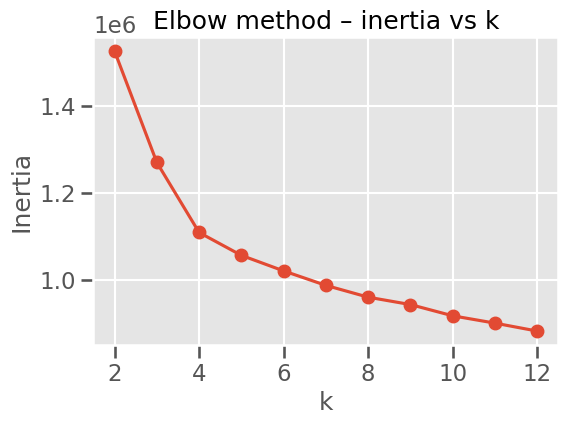

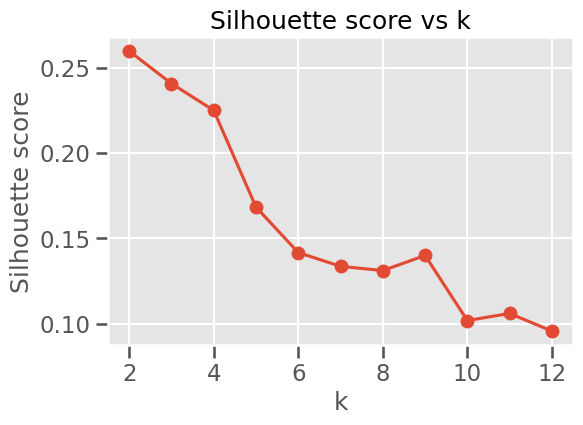

k=2 → silhouette=0.2598
k=3 → silhouette=0.2408
k=4 → silhouette=0.2250
k=5 → silhouette=0.1683
k=6 → silhouette=0.1416
k=7 → silhouette=0.1336
k=8 → silhouette=0.1311
k=9 → silhouette=0.1399
k=10 → silhouette=0.1018
k=11 → silhouette=0.1059
k=12 → silhouette=0.0956


In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertias = []
sil_scores = []
K = range(2, 13)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(df_scaled)

    inertias.append(km.inertia_)
    sil = silhouette_score(df_scaled, labels)
    sil_scores.append(sil)

# --- ELBOW ---
plt.figure(figsize=(6,4))
plt.plot(K, inertias, marker='o')
plt.title("Elbow method – inertia vs k")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

# --- SILHOUETTE ---
plt.figure(figsize=(6,4))
plt.plot(K, sil_scores, marker='o')
plt.title("Silhouette score vs k")
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.grid(True)
plt.show()

for k, s in zip(K, sil_scores):
    print(f"k={k} → silhouette={s:.4f}")


Kmeans

In [11]:
k = 4   # pocet clusteru

km = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = km.fit_predict(df_scaled)

df_scaled["cluster"] = labels
df["cluster"] = labels

print(f"KMeans hotový pro k={k}")
print("Počet položek v jednotlivých clusterech:")
print(df["cluster"].value_counts().sort_index())

KMeans hotový pro k=4
Počet položek v jednotlivých clusterech:
cluster
0    24708
1    23187
2    36657
3    15448
Name: count, dtype: int64


Poměr laptopů a desktopů v clusterech

In [12]:
import plotly.express as px

# Kontingenční tabulka
ct = df.groupby(["cluster", "device_type"]).size().reset_index(name="count")

fig = px.bar(
    ct,
    x="cluster",
    y="count",
    color="device_type",
    barmode="group",
    text="count",
    title="Zastoupení Laptop / Desktop v jednotlivých clusterech"
)

fig.update_traces(textposition="outside")
fig.show()


Je jasně vidět že se clustery vytvořily dle laptop x desktop zaměříme se tedy jen na desktop

In [13]:
df_desktop = df[df["device_type"] != "Laptop"].copy()

print("Původní dataset:", df.shape)
print("Desktop-only dataset:", df_desktop.shape)

df_desktop.head()

Původní dataset: (100000, 34)
Desktop-only dataset: (40156, 34)


,device_type,brand,model,release_year,os,form_factor,cpu_brand,cpu_model,cpu_tier,cpu_cores,cpu_threads,cpu_base_ghz,cpu_boost_ghz,gpu_brand,gpu_model,gpu_tier,vram_gb,ram_gb,storage_type,storage_gb,storage_drive_count,display_type,display_size_in,resolution,refresh_hz,battery_wh,charger_watts,psu_watts,wifi,bluetooth,weight_kg,warranty_months,price,cluster
0,Desktop,Samsung,Samsung Forge XDI,2022,Windows,ATX,Intel,Intel i5-11129,3,12,24,2.8,3.8,NVIDIA,RTX 40 60,2,6,16,NVMe,1024,1,LED,27.0,2560x1440,90,0,0,750,Wi-Fi 6,5.1,11.0,36,1383.99,0
2,Desktop,Lenovo,Lenovo Strix BIE,2024,macOS,SFF,AMD,AMD Ryzen 5 5168,2,8,16,2.6,3.6,NVIDIA,RTX 40 50,1,4,8,NVMe,512,2,LED,32.0,3440x1440,120,0,0,850,Wi-Fi 6,5.0,7.0,24,1879.99,0
3,Desktop,Dell,Dell Cube AXR,2024,Windows,ATX,AMD,AMD Ryzen 5 7550,2,6,12,2.6,3.6,AMD,RX 7000 60,2,6,16,HDD,512,2,IPS,27.0,3440x1440,120,0,0,650,Wi-Fi 6,5.2,6.0,36,1331.99,0
5,Desktop,MSI,MSI Think KSG,2025,Windows,ATX,Intel,Intel i7-10369,5,16,32,3.2,4.3,NVIDIA,RTX 40 90,6,16,96,NVMe,512,2,LED,24.0,2560x1440,90,0,0,1000,Wi-Fi 5,5.0,9.0,36,2751.99,3
6,Desktop,Apple,Apple Arena R5Q,2024,Windows,ATX,Apple,Apple M2,2,6,6,2.6,3.5,Apple,Apple Integrated,1,0,8,Hybrid,2048,2,VA,32.0,2560x1440,60,0,0,850,Wi-Fi 6,5.1,9.0,24,1609.99,0


Znovu použijeme standart scaler

In [14]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# --- použijeme desktop-only dataset ---
df_input = df_desktop

cat_keep = ["device_type", "os", "cpu_brand", "gpu_brand"]

cat_drop = [
    "brand",
    "form_factor",
    "storage_type",
    "display_type",
    "resolution",
    "wifi",
    "model",
    "cpu_model",
    "gpu_model",
]

num_keep = [
    "release_year",
    "cpu_tier",
    "cpu_cores",
    "cpu_threads",
    "cpu_base_ghz",
    "cpu_boost_ghz",
    "gpu_tier",
    "vram_gb",
    "ram_gb",
    "storage_gb",
    "storage_drive_count",
    "display_size_in",
    "refresh_hz",
    "battery_wh",
    "charger_watts",
    "psu_watts",
    "bluetooth",
    "weight_kg",
    "warranty_months",
]

target_like = ["price"]  # nepatří do scaled datasetu


df_features = df_input[cat_keep + num_keep].copy()

df_encoded = pd.get_dummies(df_features, columns=cat_keep, drop_first=True)

scaler = StandardScaler()
df_encoded[num_keep] = scaler.fit_transform(df_encoded[num_keep])

df_scaled_desktop = df_encoded

print("Shape df_scaled_desktop:", df_scaled_desktop.shape)
df_scaled_desktop.head()


Shape df_scaled_desktop: (40156, 27)


,release_year,cpu_tier,cpu_cores,cpu_threads,cpu_base_ghz,cpu_boost_ghz,gpu_tier,vram_gb,ram_gb,storage_gb,storage_drive_count,display_size_in,refresh_hz,battery_wh,charger_watts,psu_watts,bluetooth,weight_kg,warranty_months,os_Linux,os_Windows,os_macOS,cpu_brand_Apple,cpu_brand_Intel,gpu_brand_Apple,gpu_brand_Intel,gpu_brand_NVIDIA
0,-0.156531,-0.104017,0.250008,0.432106,-0.104017,0.108329,-0.798890,-0.101531,-0.778866,0.160428,-1.089975,-0.245421,-0.196782,0.0,0.0,0.367661,0.059872,0.889526,1.354569,False,True,False,False,True,False,False,True
2,0.832638,-0.832336,-0.534008,-0.382678,-0.832336,-0.581174,-1.485538,-0.589162,-1.022616,-0.502481,-0.045443,1.244530,0.495759,0.0,0.0,0.882985,-0.347828,-0.419048,0.181702,False,False,True,False,False,False,False,True
3,0.832638,-0.832336,-0.926016,-0.790070,-0.832336,-0.581174,-0.798890,-0.101531,-0.778866,-0.502481,-0.045443,-0.245421,0.495759,0.0,0.0,-0.147664,0.467571,-0.746191,1.354569,False,True,False,False,False,False,False,False
5,1.327222,1.352621,1.034024,1.246889,1.352621,1.832087,1.947704,2.336623,1.658640,-0.502481,-0.045443,-1.139392,-0.196782,0.0,0.0,1.655971,-0.347828,0.235239,1.354569,False,True,False,False,True,False,False,True
6,0.832638,-0.832336,-0.926016,-1.401157,-0.832336,-0.925925,-1.485538,-1.564423,-1.022616,1.486246,-0.045443,1.244530,-0.889322,0.0,0.0,0.882985,0.059872,0.235239,0.181702,False,True,False,True,False,True,False,False


elbow + silhouette

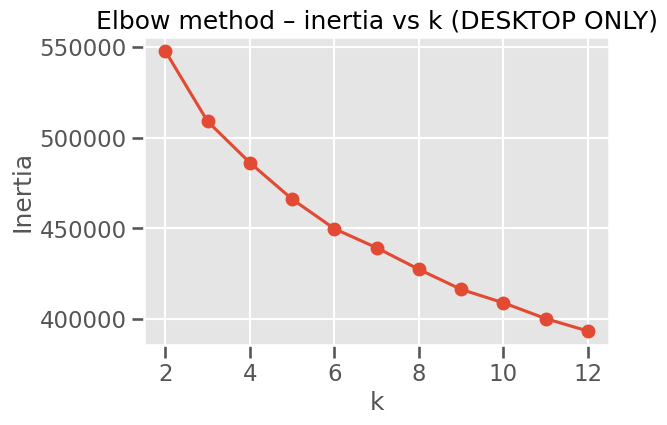

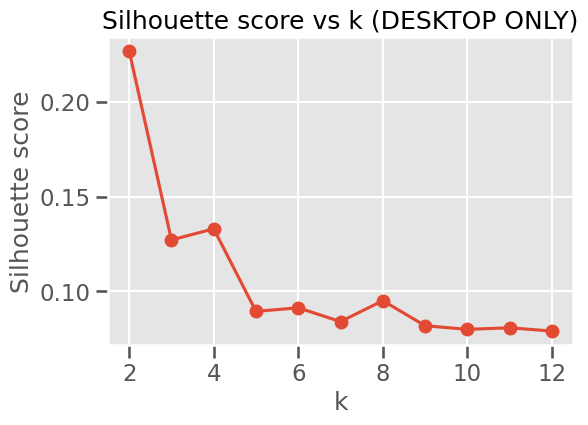

k=2 → silhouette=0.2269
k=3 → silhouette=0.1271
k=4 → silhouette=0.1330
k=5 → silhouette=0.0894
k=6 → silhouette=0.0913
k=7 → silhouette=0.0840
k=8 → silhouette=0.0950
k=9 → silhouette=0.0818
k=10 → silhouette=0.0799
k=11 → silhouette=0.0807
k=12 → silhouette=0.0790


In [15]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertias = []
sil_scores = []
K = range(2, 13)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(df_scaled_desktop)

    inertias.append(km.inertia_)
    sil = silhouette_score(df_scaled_desktop, labels)
    sil_scores.append(sil)

# --- ELBOW ---
plt.figure(figsize=(6,4))
plt.plot(K, inertias, marker='o')
plt.title("Elbow method – inertia vs k (DESKTOP ONLY)")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

# --- SILHOUETTE ---
plt.figure(figsize=(6,4))
plt.plot(K, sil_scores, marker='o')
plt.title("Silhouette score vs k (DESKTOP ONLY)")
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.grid(True)
plt.show()

# výpis hodnot
for k, s in zip(K, sil_scores):
    print(f"k={k} → silhouette={s:.4f}")


KMeans

In [16]:
k = 4   # pocet clusteru

km = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = km.fit_predict(df_scaled_desktop)

df_scaled_desktop["cluster"] = labels
df_desktop["cluster"] = labels # Assign labels to df_desktop

print(f"KMeans hotový pro k={k}")
print("Počet položek v jednotlivých clusterech:")
print(df_desktop["cluster"].value_counts().sort_index())

KMeans hotový pro k=4
Počet položek v jednotlivých clusterech:
cluster
0     2037
1     7030
2    16590
3    14499
Name: count, dtype: int64


Pohled na data

In [17]:
fig = px.box(
    df_desktop,
    x="cluster",
    y="price",
    color="cluster",
    title="Cena podle clusteru (boxplot) - Desktop Only"
)
fig.show()

In [18]:
cluster_means_desktop = df_desktop.groupby("cluster")[["cpu_tier", "gpu_tier", "ram_gb", "vram_gb", "cpu_cores"]].mean().reset_index()

fig = px.bar(
    cluster_means_desktop,
    x="cluster",
    y=["cpu_tier", "gpu_tier", "ram_gb", "vram_gb", "cpu_cores"],
    barmode="group",
    title="Průměrné HW hodnoty a cena v jednotlivých clusterech pro Desktopy"
)
fig.show()

Vyzkoušíme pro porovnání GMM, mohl by data lépe rozdělit

In [19]:

from sklearn.mixture import GaussianMixture

k = 4  # stejný počet clusterů jako u KMeans pro porovnání

gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
gmm_labels = gmm.fit_predict(df_scaled_desktop)

# uložíme si výsledky
df_scaled_desktop["cluster_gmm"] = gmm_labels
df_desktop["cluster_gmm"] = gmm_labels

print("GMM hotový pro k =", k)
print(df_desktop["cluster_gmm"].value_counts().sort_index())


GMM hotový pro k = 4
cluster_gmm
0     2037
1    16590
2    14499
3     7030
Name: count, dtype: int64


In [20]:
from sklearn.metrics import silhouette_score

sil_gmm = silhouette_score(df_scaled_desktop, gmm_labels)
print("Silhouette (GMM):", sil_gmm)


Silhouette (GMM): 0.17580380821596195


Pohled na clusterizované data

In [21]:
import plotly.express as px

fig = px.box(
    df_desktop,
    x="cluster_gmm",
    y="price",
    color="cluster_gmm",
    title="Rozložení ceny podle clusteru (GMM)",
)
fig.show()


In [22]:
fig = px.box(
    df_desktop,
    x="cluster_gmm",
    y="cpu_tier",
    color="cluster_gmm",
    title="CPU tier podle clusteru (GMM)",
)
fig.show()


In [23]:
fig = px.box(
    df_desktop,
    x="cluster_gmm",
    y="gpu_tier",
    color="cluster_gmm",
    title="GPU tier podle clusteru (GMM)",
)
fig.show()


In [24]:
cluster_means = df_desktop.groupby("cluster_gmm")["ram_gb"].mean().reset_index()

fig = px.bar(
    cluster_means,
    x="cluster_gmm",
    y="ram_gb",
    title="Průměrná RAM podle clusteru",
    text="ram_gb"
)
fig.show()


In [25]:
cluster_summary = df_desktop.groupby("cluster_gmm")[
    ["cpu_tier", "gpu_tier", "ram_gb", "vram_gb"]
].mean().reset_index()

fig = px.bar(
    cluster_summary,
    x="cluster_gmm",
    y=["cpu_tier", "gpu_tier", "ram_gb", "vram_gb"],
    barmode="group",
    title="Průměrné HW parametry podle clusteru"
)
fig.show()


In [26]:
numeric_means = df_desktop.groupby("cluster_gmm")[
    ["price", "cpu_tier", "gpu_tier", "ram_gb", "vram_gb", "storage_gb",
     "cpu_cores", "cpu_threads", "refresh_hz", "display_size_in",
     "battery_wh", "charger_watts", "psu_watts", "weight_kg"]
].mean()

numeric_means


,price,cpu_tier,gpu_tier,ram_gb,vram_gb,storage_gb,cpu_cores,cpu_threads,refresh_hz,display_size_in,battery_wh,charger_watts,psu_watts,weight_kg
cluster_gmm,,,,,,,,,,,,,,
0,1711.068056,2.821797,2.852234,32.392734,5.884143,890.281787,9.327442,17.202749,97.846834,27.664703,0.0,0.0,677.933235,8.332351
1,1912.272459,3.503315,3.544605,43.429536,7.012417,901.678602,11.038457,20.551175,98.581736,27.821941,0.0,0.0,678.056058,8.284509
2,1412.136631,1.753431,1.769432,13.400648,4.386785,893.024898,6.438651,11.976550,98.557211,27.829161,0.0,0.0,678.326091,8.256225
3,2472.410484,5.250640,5.229303,97.897013,9.350213,913.770697,19.227596,34.671693,98.517354,27.862020,0.0,0.0,680.953058,8.308535


# Popis a porovnání Clusteringu

In [35]:
import plotly.graph_objects as go

sankey_data = df_desktop.groupby(['cluster', 'cluster_gmm']).size().reset_index(name='count')
n_components = 4

source = sankey_data['cluster'].tolist()
target = (sankey_data['cluster_gmm'] + n_components).tolist()
value = sankey_data['count'].tolist()

label_list = [f"K-Means {i}" for i in range(n_components)] + \
             [f"GMM {i}" for i in range(n_components)]

node_colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"] * 2

fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=label_list,
        color=node_colors
    ),
    link=dict(
        source=source,
        target=target,
        value=value,
        color="rgba(200, 200, 200, 0.5)"
    )
)])

fig.update_layout(title_text="Porovnání shody clusterů: K-Means vs GMM (Sankey Diagram)", font_size=12)
fig.show()

Tady lze vidět že KMeans i GMM rozdělili data totožně, což beru jako správné rozdělení do skupin

Definice clusterů do skupin

## Cluster 0 – Vyvážené mainstream sestavy (upper-mid range)

### Charakteristika
- **Cena:** ~1711 USD  
- **CPU tier:** ~2.8  
- **GPU tier:** ~2.85  
- **RAM:** ~32 GB  
- **VRAM:** ~5.9 GB  
- **CPU:** ~9 jader / 17 vláken  
- **PSU:** ~678 W  

### Interpretace / využití
- Univerzální domácí / pracovní PC.  
- Multitasking, office, střih videa, hraní ve **Full HD / 1440p**.  
- Vyvážený střední výkon.

---

## Cluster 1 – High-end výkonnostní sestavy (enthusiast / gaming)

### Charakteristika
- **Cena:** ~1908 USD  
- **CPU tier:** ~3.56  
- **GPU tier:** ~3.57  
- **RAM:** ~50 GB  
- **VRAM:** ~8.8 GB  
- **CPU:** ~12 jader / 23 vláken  
- **PSU:** ~678 W  

### Interpretace / využití
- Výkonné herní nebo pracovní stroje.  
- Render, virtualizace, AAA gaming ve vysokém rozlišení.  
- Zaměřené na výpočetní výkon (více jader, vyšší VRAM).

---

## Cluster 2 – Low-end až lower-mid range desktopová třída

### Charakteristika
- **Cena:** ~1470 USD (nejlevnější)  
- **CPU tier:** ~1.93  
- **GPU tier:** ~1.95  
- **RAM:** ~16 GB  
- **VRAM:** ~5.4 GB  
- **CPU:** ~7 jader / 12 vláken  

### Interpretace / využití
- Základní domácí/kancelářské PC.  
- Web, office, nenáročné aplikace, občasné hraní.  
- Nejnižší výkonový profil.

---

## Cluster 3 – Workstation / profesionální produktivní sestavy

### Charakteristika
- **Cena:** ~2190 USD (nejdražší)  
- **CPU tier:** ~4.12  
- **GPU tier:** ~4.15  
- **VRAM:** ~1.9 GB (velmi nízká)  
- **RAM:** ~63 GB  
- **CPU:** ~14 jader / 21 vláken  

### Interpretace / využití
- Profesionální pracovní stanice.  
- Výpočty, virtualizace, CAD, vědecký software.  
- Nízká VRAM → ne pro hry, ale pro produktivní workflow.


| Cluster | Název segmentu            | Typické využití                                         |
| ------- | ------------------------- | ------------------------------------------------------- |
| **0**   | Vyvážené mainstream PC    | Domácnost, běžná práce, mid-range gaming                |
| **1**   | High-end výkonné sestavy  | AAA gaming, render, výpočty, náročné aplikace           |
| **2**   | Low-end / kancelářské PC  | Office, web, lehké aplikace                             |
| **3**   | Profesionální workstation | Virtualizace, CAD, vědecké výpočty, server-like využití |


### Charakteristika clusterů (GMM)

Na základě průměrných hodnot (zejména RAM, GPU tier a CPU tier) a cenového rozdělení můžeme clustery interpretovat následovně:

* **Cluster 0 - Mainstream / Balanced:** Zlatá střední cesta. Počítače s vyváženým výkonem (průměrná RAM ~32GB, střední GPU tier), vhodné pro většinu uživatelů a hraní ve Full HD. Cena se pohybuje okolo průměru.

* **Cluster 1 - High-end / Performance:** Nejdražší a nejvýkonnější stroje. Vyznačují se vysokou kapacitou RAM (často >32GB), nejnovějšími grafickými kartami a procesory. Cílí na nadšence a náročné hráče.

* **Cluster 2 - Low-end / Office:** Základní sestavy s nižším výkonem (často integrovaná grafika, nižší RAM ~16GB). Ideální pro kancelářskou práci a prohlížení webu. Nejnižší cenová hladina.

* **Cluster 3 - Workstation / Compute:** Specifická skupina, často s velmi vysokou RAM, ale specifickými GPU (např. profesionální řady nebo Apple Silicon). Může zahrnovat drahé pracovní stanice, které nejsou primárně herní.

Zastoupení značek v clusterech

In [27]:
import plotly.express as px
import pandas as pd

# CPU brand share per cluster
cpu_share = (
    pd.crosstab(df_desktop["cluster_gmm"], df_desktop["cpu_brand"], normalize="index") * 100
).reset_index()

cpu_share_long = cpu_share.melt(id_vars="cluster_gmm", var_name="cpu_brand", value_name="percent")

fig = px.bar(
    cpu_share_long,
    x="cluster_gmm",
    y="percent",
    color="cpu_brand",
    barmode="group",
    title="CPU brand – procentuální zastoupení v clusterech",
    text="percent"
)
fig.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig.show()


In [28]:
# GPU brand share per cluster
gpu_share = (
    pd.crosstab(df_desktop["cluster_gmm"], df_desktop["gpu_brand"], normalize="index") * 100
).reset_index()

gpu_share_long = gpu_share.melt(id_vars="cluster_gmm", var_name="gpu_brand", value_name="percent")

fig = px.bar(
    gpu_share_long,
    x="cluster_gmm",
    y="percent",
    color="gpu_brand",
    barmode="group",
    title="GPU brand – procentuální zastoupení v clusterech",
    text="percent"
)
fig.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig.show()


Na grafu s operačními systémy lze vidět, že zastoupení odpovídá průměrnému rozložení na trhu

In [29]:
import plotly.express as px
import pandas as pd

# OS share per cluster (percent)
os_share = (
    pd.crosstab(df_desktop["cluster_gmm"], df_desktop["os"], normalize="index") * 100
).reset_index()

os_share_long = os_share.melt(id_vars="cluster_gmm", var_name="os", value_name="percent")

fig = px.bar(
    os_share_long,
    x="cluster_gmm",
    y="percent",
    color="os",
    barmode="group",
    text="percent",
    title="Operační systém – procentuální zastoupení v jednotlivých clusterech"
)

fig.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig.show()


Logika:

Každý cluster má už definované typické HW parametry (CPU tier, GPU tier, RAM…).

Cena by měla odpovídat výkonovému profilu daného clusteru.

Když je PC příliš levné vzhledem ke clusteru → podhodnocené sestavy

Když je příliš drahé vůči clusteru → nadhodnocené sestavy

Definice:

outlier = hodnoty ležící mimo Q1 – 1.5 IQR nebo Q3 + 1.5 IQR

In [30]:
import pandas as pd

outliers = []

for cl in df_desktop["cluster_gmm"].unique():
    group = df_desktop[df_desktop["cluster_gmm"] == cl]

    q1 = group["price"].quantile(0.25)
    q3 = group["price"].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    group_outliers = group[(group["price"] < lower) | (group["price"] > upper)]
    outliers.append(group_outliers)

outliers_df = pd.concat(outliers)
outliers_df


,device_type,brand,model,release_year,os,form_factor,cpu_brand,cpu_model,cpu_tier,cpu_cores,cpu_threads,cpu_base_ghz,cpu_boost_ghz,gpu_brand,gpu_model,gpu_tier,vram_gb,ram_gb,storage_type,storage_gb,storage_drive_count,display_type,display_size_in,resolution,refresh_hz,battery_wh,charger_watts,psu_watts,wifi,bluetooth,weight_kg,warranty_months,price,cluster,cluster_gmm
1021,Desktop,Samsung,Samsung Think F4E,2024,Windows,ATX,Intel,Intel i7-10807,4,12,24,3.0,3.9,NVIDIA,RTX 30 80,4,10,64,Hybrid,256,1,Mini-LED,27.0,2560x1440,90,0,0,550,Wi-Fi 6,5.0,6.0,12,4659.99,2,1
1122,Desktop,Apple,Apple Forge SJB,2019,macOS,ATX,Apple,Apple M2,4,12,12,3.0,4.1,Apple,Apple Integrated,3,2,32,SSD,512,1,OLED,27.0,3840x2160,120,0,0,1000,Wi-Fi 6,5.2,11.0,24,2884.99,2,1
1206,Desktop,Apple,Apple Cube Q7K,2022,macOS,Micro-ATX,Apple,Apple M1,4,14,14,3.0,3.8,Apple,Apple Integrated,5,4,64,HDD,256,2,LED,32.0,3840x2160,144,0,0,750,Wi-Fi 6,5.2,7.0,24,2950.99,2,1
3103,Desktop,Apple,Apple Forge H1M,2024,macOS,Full-Tower,Apple,Apple M2 Pro,5,16,16,3.2,4.0,Apple,Apple Integrated,4,0,64,Hybrid,1024,2,OLED,27.0,3440x1440,144,0,0,550,Wi-Fi 6,5.2,6.0,24,3051.99,2,1
4171,Desktop,Apple,Apple Creator 238,2022,Windows,SFF,Apple,Apple M2 Max,4,12,12,3.0,3.9,Apple,Apple Integrated,5,0,64,Hybrid,1024,2,OLED,24.0,3440x1440,120,0,0,450,Wi-Fi 6E,5.2,10.0,24,3022.99,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80074,Desktop,Apple,Apple Think 1HP,2023,macOS,Mini-ITX,Apple,Apple M3 Max,4,14,14,3.0,4.0,Apple,Apple Integrated,5,0,64,SSD,1024,3,Mini-LED,24.0,1920x1080,120,0,0,650,Wi-Fi 6,4.2,4.0,12,3022.99,0,0
83458,Desktop,Apple,Apple Strix GQ9,2020,macOS,ATX,Apple,Apple M2,5,16,16,3.2,4.2,Apple,Apple Integrated,5,0,96,HDD,4096,1,LED,27.0,3840x2160,144,0,0,750,Wi-Fi 6E,4.2,11.0,24,3186.99,0,0
86458,Desktop,Lenovo,Lenovo Strix INK,2022,macOS,ATX,Intel,Intel i7-12843,4,12,24,3.0,3.9,NVIDIA,RTX 40 80 Ti,5,12,64,NVMe,256,1,Mini-LED,27.0,2560x1440,120,0,0,750,Wi-Fi 6,4.2,11.0,24,2988.99,0,0
97028,Desktop,Apple,Apple Cube E17,2021,Windows,ATX,Apple,Apple M2 Max,5,16,16,3.2,4.2,Apple,Apple Integrated,5,2,96,SSD,2048,1,OLED,24.0,2560x1440,90,0,0,650,Wi-Fi 7,4.2,6.0,24,3386.99,0,0


In [31]:
import pandas as pd

cluster_names = {
    0: "Mainstream / balanced",
    1: "High-end performance",
    2: "Low-end / office",
    3: "Workstation / compute"
}

cluster_desc = {
    0: "Střední výkonnost, rovnováha CPU/GPU, typické domácí a univerzální PC.",
    1: "Výkonné herní nebo produktivní sestavy, vysoký výpočetní výkon.",
    2: "Základní kancelářská sestava s nižším výkonem.",
    3: "Profesionální workstation, extrémní RAM, silné CPU, vhodné pro výpočty."
}

all_underpriced = []
all_overpriced = []

for cl in sorted(df_desktop["cluster_gmm"].unique()):

    group = df_desktop[df_desktop["cluster_gmm"] == cl]

    q1 = group["price"].quantile(0.25)
    q3 = group["price"].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    # podhodnocené
    under = group[group["price"] < lower].copy()
    under["original_index"] = under.index
    all_underpriced.append(under)

    # nadhodnocené
    over = group[group["price"] > upper].copy()
    over["original_index"] = over.index
    all_overpriced.append(over)

    print("\n========================================")
    print(f"CLUSTER {cl} – {cluster_names[cl]}")
    print(cluster_desc[cl])
    print(f"Podhodnocené sestavy: {len(under)}, nadhodnocené sestavy: {len(over)}")
    print("========================================\n")

    # ---- podhodnocené (pokud existují) ----
    if len(under) > 0:
        print(">>> PODHODNOCENÉ SESTAVY (UNDERPRICED)")
        display(
            df.loc[under["original_index"]]
            .assign(
                cluster_gmm=cl,
                cluster_name=cluster_names[cl],
                outlier_reason="Podhodnocená sestava – výrazně levnější než ostatní v clusteru."
            )
        )
    else:
        print(">>> ŽÁDNÉ PODHODNOCENÉ SESTAVY V TOMTO CLUSTERY")

    # ---- nadhodnocené (pokud existují) ----
    if len(over) > 0:
        print("\n>>> NADHODNOCENÉ SESTAVY (OVERPRICED)")
        display(
            df.loc[over["original_index"]]
            .assign(
                cluster_gmm=cl,
                cluster_name=cluster_names[cl],
                outlier_reason="Nadhodnocená sestava – výrazně dražší než ostatní v clusteru."
            )
        )
    else:
        print("\n>>> ŽÁDNÉ NADHODNOCENÉ SESTAVY V TOMTO CLUSTERY")

# Concatenate all collected outliers into single DataFrames
overpriced_full = pd.concat(all_overpriced) if all_overpriced else pd.DataFrame()
underpriced_full = pd.concat(all_underpriced) if all_underpriced else pd.DataFrame()

print("\n========================================")
print(f"Celkem podhodnocených sestav: {len(underpriced_full)}")
print(f"Celkem nadhodnocených sestav: {len(overpriced_full)}")
print("========================================")


CLUSTER 0 – Mainstream / balanced
Střední výkonnost, rovnováha CPU/GPU, typické domácí a univerzální PC.
Podhodnocené sestavy: 0, nadhodnocené sestavy: 13

>>> ŽÁDNÉ PODHODNOCENÉ SESTAVY V TOMTO CLUSTERY

>>> NADHODNOCENÉ SESTAVY (OVERPRICED)


,device_type,brand,model,release_year,os,form_factor,cpu_brand,cpu_model,cpu_tier,cpu_cores,cpu_threads,cpu_base_ghz,cpu_boost_ghz,gpu_brand,gpu_model,gpu_tier,vram_gb,ram_gb,storage_type,storage_gb,storage_drive_count,display_type,display_size_in,resolution,refresh_hz,battery_wh,charger_watts,psu_watts,wifi,bluetooth,weight_kg,warranty_months,price,cluster,cluster_gmm,cluster_name,outlier_reason
14130,Desktop,Apple,Apple Pro DAU,2023,macOS,Micro-ATX,Apple,Apple M2,5,16,16,3.2,4.2,Apple,Apple Integrated,6,4,96,SSD,512,3,OLED,24.0,3440x1440,120,0,0,750,Wi-Fi 6,4.2,7.0,48,3973.99,3,0,Mainstream / balanced,Nadhodnocená sestava – výrazně dražší než osta...
39660,Desktop,Apple,Apple Think 4LQ,2023,Windows,SFF,Apple,Apple M3 Pro,5,16,16,3.2,4.0,Apple,Apple Integrated,5,2,96,SSD,512,2,OLED,34.0,1920x1080,60,0,0,300,Wi-Fi 6E,4.2,12.0,36,3052.99,3,0,Mainstream / balanced,Nadhodnocená sestava – výrazně dražší než osta...
59062,Desktop,Apple,Apple Strix 0OW,2024,Windows,Micro-ATX,Apple,Apple M1 Max,5,16,16,3.2,4.2,Apple,Apple Integrated,4,0,64,NVMe,1024,1,IPS,32.0,3840x2160,120,0,0,550,Wi-Fi 6,4.2,4.0,12,2975.99,3,0,Mainstream / balanced,Nadhodnocená sestava – výrazně dražší než osta...
66364,Desktop,Apple,Apple Station MT8,2021,Windows,Full-Tower,Apple,Apple M1 Pro,5,16,16,3.2,4.2,Apple,Apple Integrated,6,4,96,NVMe,512,2,LED,24.0,2560x1440,120,0,0,450,Wi-Fi 6E,4.2,12.0,36,3174.99,3,0,Mainstream / balanced,Nadhodnocená sestava – výrazně dražší než osta...
71488,Desktop,Apple,Apple Forge GZK,2023,Linux,ATX,Apple,Apple M1 Max,5,16,16,3.2,4.1,Apple,Apple Integrated,5,4,96,SSD,1024,1,Mini-LED,27.0,2560x1440,60,0,0,650,Wi-Fi 6,4.2,4.0,36,3168.99,3,0,Mainstream / balanced,Nadhodnocená sestava – výrazně dražší než osta...
74445,Desktop,Apple,Apple Creator 35J,2020,Windows,Micro-ATX,Apple,Apple M3 Max,4,12,12,3.0,3.8,Apple,Apple Integrated,5,0,72,NVMe,512,2,OLED,27.0,2560x1440,90,0,0,450,Wi-Fi 6,4.2,12.0,24,3353.99,3,0,Mainstream / balanced,Nadhodnocená sestava – výrazně dražší než osta...
75985,Desktop,Apple,Apple Station 0YO,2024,Windows,SFF,Apple,Apple M1 Max,5,20,20,3.2,4.1,Apple,Apple Integrated,5,0,96,Hybrid,256,1,Mini-LED,24.0,3440x1440,144,0,0,650,Wi-Fi 6E,4.2,10.0,12,3273.99,3,0,Mainstream / balanced,Nadhodnocená sestava – výrazně dražší než osta...
76759,Desktop,Apple,Apple Strix 0O8,2018,Windows,Full-Tower,Apple,Apple M2 Pro,5,16,16,3.2,4.1,Apple,Apple Integrated,5,2,96,NVMe,2048,3,OLED,24.0,3840x2160,60,0,0,650,Wi-Fi 6E,4.2,8.0,24,3353.99,3,0,Mainstream / balanced,Nadhodnocená sestava – výrazně dražší než osta...
80074,Desktop,Apple,Apple Think 1HP,2023,macOS,Mini-ITX,Apple,Apple M3 Max,4,14,14,3.0,4.0,Apple,Apple Integrated,5,0,64,SSD,1024,3,Mini-LED,24.0,1920x1080,120,0,0,650,Wi-Fi 6,4.2,4.0,12,3022.99,3,0,Mainstream / balanced,Nadhodnocená sestava – výrazně dražší než osta...
83458,Desktop,Apple,Apple Strix GQ9,2020,macOS,ATX,Apple,Apple M2,5,16,16,3.2,4.2,Apple,Apple Integrated,5,0,96,HDD,4096,1,LED,27.0,3840x2160,144,0,0,750,Wi-Fi 6E,4.2,11.0,24,3186.99,3,0,Mainstream / balanced,Nadhodnocená sestava – výrazně dražší než osta...



CLUSTER 1 – High-end performance
Výkonné herní nebo produktivní sestavy, vysoký výpočetní výkon.
Podhodnocené sestavy: 16, nadhodnocené sestavy: 151

>>> PODHODNOCENÉ SESTAVY (UNDERPRICED)


,device_type,brand,model,release_year,os,form_factor,cpu_brand,cpu_model,cpu_tier,cpu_cores,cpu_threads,cpu_base_ghz,cpu_boost_ghz,gpu_brand,gpu_model,gpu_tier,vram_gb,ram_gb,storage_type,storage_gb,storage_drive_count,display_type,display_size_in,resolution,refresh_hz,battery_wh,charger_watts,psu_watts,wifi,bluetooth,weight_kg,warranty_months,price,cluster,cluster_gmm,cluster_name,outlier_reason
5120,Desktop,ASUS,ASUS Pro 353,2024,Windows,ATX,Intel,Intel i7-11309,4,12,24,3.0,4.0,Apple,Apple Integrated,4,2,64,Hybrid,1024,3,QLED,27.0,1920x1080,60,0,0,450,Wi-Fi 6,5.2,8.0,12,847.99,3,1,High-end performance,Podhodnocená sestava – výrazně levnější než os...
12660,Desktop,HP,HP Cube FIR,2019,Windows,ATX,AMD,AMD Ryzen 7 5246,4,12,24,3.0,3.9,Intel,Arc A580,3,6,32,NVMe,512,1,VA,32.0,1920x1080,240,0,0,750,Wi-Fi 6,5.2,9.0,12,582.99,3,1,High-end performance,Podhodnocená sestava – výrazně levnější než os...
22136,Desktop,ASUS,ASUS Station 7N7,2018,ChromeOS,SFF,Intel,Intel i5-10151,3,8,16,2.8,3.8,NVIDIA,RTX 40 60,2,6,16,Hybrid,512,3,LED,24.0,1920x1080,60,0,0,550,Wi-Fi 6E,5.2,8.0,12,845.99,0,1,High-end performance,Podhodnocená sestava – výrazně levnější než os...
24197,Desktop,ASUS,ASUS Think 3Y2,2023,Windows,ATX,Intel,Intel i7-14728,4,12,24,3.0,4.0,Apple,Apple Integrated,3,0,32,NVMe,512,2,OLED,27.0,1920x1080,90,0,0,650,Wi-Fi 6,5.0,12.0,24,847.99,0,1,High-end performance,Podhodnocená sestava – výrazně levnější než os...
39721,Desktop,Acer,Acer Forge PH1,2021,Windows,ATX,AMD,AMD Ryzen 5 4132,3,10,20,2.8,3.7,NVIDIA,RTX 40 60,2,6,16,NVMe,256,1,LED,24.0,1920x1080,60,0,0,850,Wi-Fi 6,5.2,13.0,36,866.99,0,1,High-end performance,Podhodnocená sestava – výrazně levnější než os...
43215,Desktop,Lenovo,Lenovo Forge TCZ,2024,Windows,ATX,Intel,Intel i5-13573,3,10,20,2.8,3.9,NVIDIA,RTX 40 60,2,6,16,Hybrid,512,3,OLED,27.0,1920x1080,144,0,0,300,Wi-Fi 6E,5.0,8.0,12,796.99,0,1,High-end performance,Podhodnocená sestava – výrazně levnější než os...
51977,Desktop,Dell,Dell Think N9I,2020,Linux,ATX,AMD,AMD Ryzen 5 3975,3,10,20,2.8,3.7,NVIDIA,RTX 40 70,3,8,32,SSD,1024,3,QLED,27.0,3440x1440,120,0,0,550,Wi-Fi 6,5.2,4.0,36,861.99,0,1,High-end performance,Podhodnocená sestava – výrazně levnější než os...
53682,Desktop,Dell,Dell Creator UQJ,2019,Windows,Mini-ITX,Intel,Intel i7-13219,4,12,24,3.0,4.0,NVIDIA,RTX 30 80,4,10,64,NVMe,512,1,LED,27.0,1920x1080,90,0,0,850,Wi-Fi 5,5.2,5.0,24,602.99,3,1,High-end performance,Podhodnocená sestava – výrazně levnější než os...
59541,Desktop,HP,HP Cube 2P0,2025,ChromeOS,Full-Tower,Intel,Intel i5-12290,3,10,20,2.8,3.9,NVIDIA,RTX 40 60,2,6,16,HDD,1024,1,LED,24.0,1920x1080,60,0,0,550,Wi-Fi 6,5.2,6.0,12,905.99,0,1,High-end performance,Podhodnocená sestava – výrazně levnější než os...
60588,Desktop,HP,HP Creator 7J5,2024,Windows,Mini-ITX,Intel,Intel i5-14533,3,8,16,2.8,3.6,NVIDIA,RTX 20 70,3,8,32,NVMe,512,2,IPS,32.0,1920x1080,60,0,0,750,Wi-Fi 6E,5.0,9.0,12,774.99,0,1,High-end performance,Podhodnocená sestava – výrazně levnější než os...



>>> NADHODNOCENÉ SESTAVY (OVERPRICED)


...


CLUSTER 3 – Workstation / compute
Profesionální workstation, extrémní RAM, silné CPU, vhodné pro výpočty.
Podhodnocené sestavy: 7, nadhodnocené sestavy: 80

>>> PODHODNOCENÉ SESTAVY (UNDERPRICED)


,device_type,brand,model,release_year,os,form_factor,cpu_brand,cpu_model,cpu_tier,cpu_cores,cpu_threads,cpu_base_ghz,cpu_boost_ghz,gpu_brand,gpu_model,gpu_tier,vram_gb,ram_gb,storage_type,storage_gb,storage_drive_count,display_type,display_size_in,resolution,refresh_hz,battery_wh,charger_watts,psu_watts,wifi,bluetooth,weight_kg,warranty_months,price,cluster,cluster_gmm,cluster_name,outlier_reason
43501,Desktop,Razer,Razer Station U8Y,2019,Windows,SFF,Intel,Intel i7-13736,5,16,32,3.2,4.1,NVIDIA,RTX 30 80 Ti,5,12,96,NVMe,2048,2,IPS,34.0,2560x1440,90,0,0,1000,Wi-Fi 6,5.0,7.0,36,869.99,3,3,Workstation / compute,Podhodnocená sestava – výrazně levnější než os...
60711,Desktop,Dell,Dell Arena APS,2023,Windows,Micro-ATX,Intel,Intel i7-11336,5,16,32,3.2,4.1,NVIDIA,RTX 40 80,4,10,64,NVMe,512,1,OLED,32.0,2560x1440,60,0,0,550,Wi-Fi 6,5.0,8.0,24,942.99,3,3,Workstation / compute,Podhodnocená sestava – výrazně levnější než os...
70995,Desktop,MSI,MSI Creator VJ5,2021,Linux,Micro-ATX,Intel,Intel i7-10645,5,18,36,3.2,4.1,NVIDIA,RTX 30 80,4,10,64,NVMe,256,4,LED,32.0,2560x1440,120,0,0,750,Wi-Fi 6,5.0,7.0,24,662.99,3,3,Workstation / compute,Podhodnocená sestava – výrazně levnější než os...
84706,Desktop,ASUS,ASUS Station WVZ,2021,ChromeOS,SFF,Intel,Intel i7-12880,5,16,32,3.2,4.1,NVIDIA,RTX 30 80,4,10,64,NVMe,512,1,VA,32.0,2560x1440,60,0,0,650,Wi-Fi 6,5.1,4.0,24,588.99,3,3,Workstation / compute,Podhodnocená sestava – výrazně levnější než os...
86184,Desktop,Dell,Dell Cube V7G,2023,Windows,ATX,AMD,AMD Ryzen 7 7103,5,18,36,3.2,4.2,NVIDIA,RTX 40 80 Ti,5,12,96,HDD,1024,3,Mini-LED,27.0,1920x1080,120,0,0,550,Wi-Fi 6,5.1,15.0,12,899.99,3,3,Workstation / compute,Podhodnocená sestava – výrazně levnější než os...
87848,Desktop,Acer,Acer Strix OW9,2019,Windows,Micro-ATX,AMD,AMD Ryzen 7 6454,5,18,36,3.2,4.1,Intel,Arc A700,4,0,64,NVMe,1024,2,LED,27.0,2560x1440,60,0,0,850,Wi-Fi 6,5.1,16.0,24,1280.99,3,3,Workstation / compute,Podhodnocená sestava – výrazně levnější než os...
94080,Desktop,ASUS,ASUS Forge 8WE,2018,Windows,ATX,Intel,Intel i7-12822,5,16,32,3.2,4.2,AMD,RX 7000 90,6,16,96,Hybrid,256,3,OLED,34.0,1920x1080,90,0,0,750,Wi-Fi 6,5.0,7.0,24,1065.99,3,3,Workstation / compute,Podhodnocená sestava – výrazně levnější než os...



>>> NADHODNOCENÉ SESTAVY (OVERPRICED)


,device_type,brand,model,release_year,os,form_factor,cpu_brand,cpu_model,cpu_tier,cpu_cores,cpu_threads,cpu_base_ghz,cpu_boost_ghz,gpu_brand,gpu_model,gpu_tier,vram_gb,ram_gb,storage_type,storage_gb,storage_drive_count,display_type,display_size_in,resolution,refresh_hz,battery_wh,charger_watts,psu_watts,wifi,bluetooth,weight_kg,warranty_months,price,cluster,cluster_gmm,cluster_name,outlier_reason
2300,Desktop,Apple,Apple Cube X53,2020,macOS,SFF,Apple,Apple M3,6,24,24,3.4,4.3,Apple,Apple Integrated,5,0,96,SSD,1024,1,OLED,24.0,2560x1440,120,0,0,550,Wi-Fi 6,5.0,6.0,12,3703.99,3,3,Workstation / compute,Nadhodnocená sestava – výrazně dražší než osta...
2855,Desktop,Apple,Apple Station VXJ,2018,Windows,ATX,Apple,Apple M3 Max,6,28,28,3.4,4.4,Apple,Apple Integrated,6,2,136,NVMe,512,3,QLED,27.0,1920x1080,120,0,0,650,Wi-Fi 6,5.2,10.0,12,7717.99,3,3,Workstation / compute,Nadhodnocená sestava – výrazně dražší než osta...
4232,Desktop,Apple,Apple Station IVY,2022,Windows,Full-Tower,Apple,Apple M2 Pro,5,16,16,3.2,4.1,Apple,Apple Integrated,5,4,96,NVMe,1024,4,Mini-LED,27.0,3840x2160,120,0,0,650,Wi-Fi 6,5.0,6.0,24,3557.99,3,3,Workstation / compute,Nadhodnocená sestava – výrazně dražší než osta...
4318,Desktop,Apple,Apple Forge 9WH,2022,Windows,SFF,Apple,Apple M3,6,26,26,3.4,4.3,Apple,Apple Integrated,6,4,128,NVMe,512,1,OLED,27.0,1920x1080,60,0,0,750,Wi-Fi 5,5.0,9.0,48,3579.99,3,3,Workstation / compute,Nadhodnocená sestava – výrazně dražší než osta...
5602,Desktop,Dell,Dell Pro 1NJ,2023,Windows,Mini-ITX,Intel,Intel i7-10820,5,20,40,3.2,4.3,NVIDIA,RTX 30 90,6,16,96,NVMe,1024,1,LED,24.0,3440x1440,60,0,0,750,Wi-Fi 6,5.0,7.0,24,5601.99,3,3,Workstation / compute,Nadhodnocená sestava – výrazně dražší než osta...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95526,Desktop,Apple,Apple Station WBR,2018,macOS,Micro-ATX,Apple,Apple M1,6,26,26,3.4,4.4,Apple,Apple Integrated,6,0,128,SSD,2048,3,OLED,24.0,1920x1080,120,0,0,1200,Wi-Fi 5,5.1,5.0,12,3786.99,3,3,Workstation / compute,Nadhodnocená sestava – výrazně dražší než osta...
95837,Desktop,Apple,Apple Cube ULG,2022,Windows,ATX,Apple,Apple M2,6,28,28,3.4,4.5,Apple,Apple Integrated,6,0,128,NVMe,1024,1,Mini-LED,24.0,3440x1440,60,0,0,1000,Wi-Fi 6,5.3,5.0,12,3716.99,3,3,Workstation / compute,Nadhodnocená sestava – výrazně dražší než osta...
98868,Desktop,Apple,Apple Arena YCQ,2024,Windows,SFF,Apple,Apple M1 Pro,6,26,26,3.4,4.3,Apple,Apple Integrated,6,4,128,SSD,256,3,OLED,32.0,3840x2160,120,0,0,550,Wi-Fi 5,5.2,6.0,24,3623.99,3,3,Workstation / compute,Nadhodnocená sestava – výrazně dražší než osta...
99018,Desktop,Apple,Apple Strix VNV,2025,Windows,SFF,Apple,Apple M3,5,16,16,3.2,4.2,Apple,Apple Integrated,6,0,96,NVMe,256,3,OLED,27.0,2560x1440,60,0,0,650,Wi-Fi 6,5.0,12.0,12,3603.99,3,3,Workstation / compute,Nadhodnocená sestava – výrazně dražší než osta...



Celkem podhodnocených sestav: 28
Celkem nadhodnocených sestav: 411


Podíváme se ještě na nadhodnocené značky a výrobce

In [32]:
brand_percent = (
    overpriced_full["brand"].value_counts(normalize=True) * 100
).reset_index()

brand_percent.columns = ["brand", "percent"]

fig = px.bar(
    brand_percent,
    x="brand",
    y="percent",
    title="Procentuální zastoupení nadhodnocených značek",
    text="percent"
)
fig.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig.show()


In [33]:
brand_percent_under = (
    underpriced_full["brand"].value_counts(normalize=True) * 100
).reset_index()

brand_percent_under.columns = ["brand", "percent"]

fig = px.bar(
    brand_percent_under,
    x="brand",
    y="percent",
    title="Procentuální zastoupení podhodnocených značek",
    text="percent"
)

fig.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig.show()


Závěr

Apple je zdaleka nejvýraznějším představitelem nadhodnoceného segmentu, což potvrdilo očekávané chování prémiové značky.

HP, Samsung a Acer se ukázaly jako značky, které nejčastěji nabízejí podhodnocené (výhodné) sestavy.

Ostatní značky se pohybují uprostřed — někdy nabídnou výhodný model, jindy prémiově naceněný produkt.

Analýza ukázala, že cenová politika značek není rovnoměrná a velmi úzce souvisí s typem zařízení, cílovým segmentem i positioningem v trhu.

# Shrnutí

V této analýze jsme aplikovali shlukovací algoritmy **K-Means** a **Gaussian Mixture Models (GMM)** na dataset cen počítačů s cílem identifikovat tržní segmenty a cenové anomálie.

**Klíčové poznatky:**

1.  **Segmentace trhu:** Oba algoritmy identifikovaly **4 hlavní skupiny** počítačů, které odpovídají reálnému rozdělení trhu: Low-end (kancelář), Mainstream, High-end (herní) a Workstation.
2.  **Shoda algoritmů:** Srovnání pomocí Sankey ukázalo vysokou shodu mezi K-Means a GMM. To potvrzuje, že nalezené struktury v datech jsou robustní a nejsou dílem náhody jednoho algoritmu. GMM se ukázal jako flexibilnější pro okrajové případy.
3.  **Vliv typu zařízení:** Analýza jasně ukázala, že **laptopy a desktopy tvoří odlišné cenové a výkonnostní kategorie**, proto bylo nutné set zredukovata zaměřit se na desktopy.
4.  **Detekce outlierů:** V rámci clusterů jsme identifikovali **předražené sestavy** (outliery), jejichž cena neodpovídá parametrům daného segmentu. Tyto položky mohou indikovat chybu v nacenění, nebo prémiové značky (např. Apple), u kterých se připlácí za značku, nikoliv hrubý výkon.

## Zdroje a teoretické opodstatnění použitých metod

### Gaussian Mixture Models (GMM)
Gaussian Mixture Model je pravděpodobnostní model, který předpokládá, že data pocházejí z kombinace několika normálních distribucí. Na rozdíl od K-Means umožňuje:

- modelovat **eliptické** clustery (ne pouze kulové),
- **měkké přiřazení** – každý bod má pravděpodobnost příslušnosti ke clusteru,
- lepší popis reálných datových struktur.

- Bishop, C. M. – *Pattern Recognition and Machine Learning*, kapitola 9 (Mixture Models)  
- Murphy, K. – *Machine Learning: A Probabilistic Perspective*  
- Scikit-Learn dokumentace GMM: https://scikit-learn.org/stable/modules/mixture.html

**Zdroje:**
- Burnham, K. P. & Anderson, D. R. – *Model Selection and Multimodel Inference*  
- Wagenmakers, E.-J. – *Model Selection and Multimodel Inference*  
- https://en.wikipedia.org/wiki/Akaike_information_criterion  
- https://en.wikipedia.org/wiki/Bayesian_information_criterion  

### Outlier detection v clusterech
- **univariantně** pomocí IQR (Q1–1.5IQR, Q3+1.5IQR),

Tato metoda je vhodná, protože clustery definují přirozené skupiny a odlehlé body lze hodnotit relativně vůči jejich skupině.

**Zdroje:**
- Rousseeuw & Leroy – *Robust Regression and Outlier Detection*  
- De Maesschalck, Jouan-Rimbaud & Massart – *The Mahalanobis distance*  
- Scikit-Learn: https://scikit-learn.org/stable/modules/outlier_detection.html
